In [28]:
# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  Cell 1 – Imports & global config                                    ║
# ╚═══════════════════════════════════════════════════════════════════════╝
import os, math, random, warnings
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
from torchvision import models

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Torch {torch.__version__}  CUDA={torch.cuda.is_available()}")


✅ Torch 2.7.0+cpu  CUDA=False


In [29]:
# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  Cell 2 – Paths                                                       ║
# ╚═══════════════════════════════════════════════════════════════════════╝
BASE_DIR = r"C:\Users\yozev\OneDrive\Desktop\Shapes2"          # root folder
CSV_PATH = r"C:\Users\yozev\PycharmProjects\finetuning\majority_scores.csv"                   # uploaded CSV

# mapping shape → reference‐image path
REF_PATHS = {
    2 : rf"{BASE_DIR}\shape2\original2.png",
    3 : rf"{BASE_DIR}\shape3\original3.png",
    7 : rf"{BASE_DIR}\shape7\original7.png",
    16: rf"{BASE_DIR}\shape16\original16.png",
    17: rf"{BASE_DIR}\shape17\original17.png",
}

In [30]:
# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  Cell 3 – Allowed augmentation                                        ║
# ╚═══════════════════════════════════════════════════════════════════════╝
IMG_SIZE = 224

class BoldLines:
    def __init__(self, p=0.6, max_pct=0.4):
        self.p, self.max_iter = p, int(max_pct*10) or 1
    def __call__(self, img):
        if np.random.rand() > self.p:
            return img
        import cv2
        arr = np.array(img); kernel = np.ones((3,3), np.uint8)
        iters = np.random.randint(1, self.max_iter+1)
        arr = cv2.dilate(arr, kernel, iters)
        return Image.fromarray(arr)

train_tf = T.Compose([
    T.RandomAffine(degrees=0, translate=(.1,.1), fill=0),
    T.RandomAffine(degrees=(-5,5), fill=0),
    BoldLines(p=0.7, max_pct=0.4),
    T.ToTensor(),
    T.Lambda(lambda t: t.repeat(3,1,1)),    # to 3-ch for diff calc later
    T.RandomErasing(p=0.25, scale=(.02,.07), ratio=(.5,2.), value=0),
    T.Resize((IMG_SIZE, IMG_SIZE)),
])

val_tf = T.Compose([
    T.ToTensor(),
    T.Lambda(lambda t: t.repeat(3,1,1)),
    T.Resize((IMG_SIZE, IMG_SIZE)),
])

In [31]:
# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  Cell 4 – Dataset: (child, reference, |diff|)  → score                ║
# ╚═══════════════════════════════════════════════════════════════════════╝
class SimilarityDataset(Dataset):
    def __init__(self, csv_path:str, base_dir:str, transform, split="train"):
        df = pd.read_csv(csv_path)
        self.paths, self.labels, self.ref_imgs = [], [], {}
        self.transform = transform

        # preload reference tensors once / shape
        for shape, rpath in REF_PATHS.items():
            self.ref_imgs[shape] = val_tf(Image.open(rpath).convert('L'))

        for _,row in df.iterrows():
            shape = int(row['shape'])
            cid   = int(row['child_id'])
            score = float(row['score'])           # 0-4 float
            ipath = rf"{base_dir}\shape{shape}\{cid}.png"
            if os.path.exists(ipath) and shape in self.ref_imgs:
                self.paths.append((ipath, shape))
                self.labels.append(score/4.0)     # normalise to 0-1

        print(f"{split.capitalize()} set: {len(self.paths)} samples")

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        path, shape = self.paths[idx]
        child = Image.open(path).convert('L')
        child = self.transform(child)
        ref   = self.ref_imgs[shape]              # already 3×H×W

        diff  = torch.abs(child - ref)
        x = torch.cat([child[0:1], ref[0:1], diff[0:1]], dim=0)  # 3×H×W
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y

In [32]:
# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  Cell 5 – DataLoaders (clean val transform swap)                       ║
# ╚═══════════════════════════════════════════════════════════════════════╝
def get_loaders(batch: int = 32):
    # 1) full dataset with train_tf
    full_ds = SimilarityDataset(CSV_PATH, BASE_DIR, transform=train_tf, split="full")

    # 2) 80/20 split
    N       = len(full_ds)
    tr_len  = int(0.8 * N)
    vl_len  = N - tr_len
    tr_ds, vl_ds = random_split(
        full_ds,
        [tr_len, vl_len],
        generator=torch.Generator().manual_seed(SEED)
    )

    # 3) switch the transform on the val subset to val_tf
    vl_ds.dataset.transform = val_tf

    # 4) DataLoaders
    tr_loader = DataLoader(tr_ds, batch_size=batch, shuffle=True,  num_workers=0)
    vl_loader = DataLoader(vl_ds, batch_size=batch, shuffle=False, num_workers=0)

    print(f"\nFull set: {N} samples  →  train {len(tr_ds)}, val {len(vl_ds)}")
    return tr_loader, vl_loader


In [33]:
# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  Cell 6 – LoReFT + ResNet-18 regressor                                ║
# ╚═══════════════════════════════════════════════════════════════════════╝
class LoReFT(nn.Module):
    def __init__(self, d, rank=64):
        super().__init__()
        self.U = nn.Parameter(torch.randn(d, rank)*0.02)
        self.V = nn.Parameter(torch.randn(d, rank)*0.02)
    def forward(self, h):
        return h + (h @ self.V) @ self.U.T

def build_model(rank=64, unfreeze_last=True, p_dropout=0.3):
    backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for p in backbone.parameters():
        p.requires_grad = False
    if unfreeze_last:
        for p in backbone.layer4.parameters():
            p.requires_grad = True

    feat = backbone.fc.in_features
    backbone.fc = nn.Identity()
    model = nn.Sequential(
        backbone,                # (B, 512)
        LoReFT(feat, rank),
        nn.Dropout(p_dropout),
        nn.Linear(feat, 1),      # regression output
        nn.Sigmoid()             # map to 0–1
    ).to(DEVICE)
    return model

model = build_model()
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Trainable params: 8,459,777


In [34]:
# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  Cell 6 – LoReFT + ResNet-18 regressor                                ║
# ╚═══════════════════════════════════════════════════════════════════════╝
class LoReFT(nn.Module):
    def __init__(self, d, rank=64):
        super().__init__()
        self.U = nn.Parameter(torch.randn(d, rank)*0.02)
        self.V = nn.Parameter(torch.randn(d, rank)*0.02)
    def forward(self, h):
        return h + (h @ self.V) @ self.U.T

def build_model(rank=64, unfreeze_last=True, p_dropout=0.3):
    backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for p in backbone.parameters():
        p.requires_grad = False
    if unfreeze_last:
        for p in backbone.layer4.parameters():
            p.requires_grad = True

    feat = backbone.fc.in_features
    backbone.fc = nn.Identity()
    model = nn.Sequential(
        backbone,                # (B, 512)
        LoReFT(feat, rank),
        nn.Dropout(p_dropout),
        nn.Linear(feat, 1),      # regression output
        nn.Sigmoid()             # map to 0–1
    ).to(DEVICE)
    return model

model = build_model()
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Trainable params: 8,459,777


In [35]:
# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  Cell 8 – Fit loop                                                    ║
# ╚═══════════════════════════════════════════════════════════════════════╝
def fit(model, tr_loader, vl_loader, epochs=40, lr=3e-4, patience=8):
    loss_fn = nn.MSELoss()
    head, layer4 = [], []
    for n,p in model.named_parameters():
        if not p.requires_grad: continue
        (layer4 if "layer4" in n else head).append(p)
    opt = optim.AdamW(
        [{"params": layer4, "lr": lr*0.1},
         {"params": head,   "lr": lr     }],
        weight_decay=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-6)

    best, wait = math.inf, 0
    for ep in range(1, epochs+1):
        tr_loss, tr_mae = run_epoch(model, tr_loader, loss_fn, opt)
        vl_loss, vl_mae = run_epoch(model, vl_loader, loss_fn)
        sched.step()
        print(f"E{ep:02d}  MSE {tr_loss:.4f}->{vl_loss:.4f}  "
              f"|  MAE {vl_mae*4:.3f} (0-4)")
        if vl_loss < best-1e-4:
            best, wait = vl_loss, 0
            torch.save(model.state_dict(), "best_similarity.pth")
        else:
            wait += 1
            if wait >= patience:
                print("⏹️  Early stop"); break


In [37]:
# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  Cell 9 – Self-contained training (defines run_epoch & fit inline)    ║
# ╚═══════════════════════════════════════════════════════════════════════╝
import math
from tqdm.auto import tqdm

def run_epoch(model, loader, loss_fn, opt=None):
    train = opt is not None
    if train:
        model.train()
    else:
        model.eval()
    total_loss = 0.0
    total_mae  = 0.0
    for x, y in (tqdm(loader, leave=False) if train else loader):
        x, y = x.to(DEVICE), y.to(DEVICE).unsqueeze(1)
        if train:
            opt.zero_grad()
        pred = model(x)
        loss = loss_fn(pred, y)
        if train:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        total_loss += loss.item() * x.size(0)
        total_mae  += torch.abs(pred - y).sum().item()
    n = len(loader.dataset)
    return total_loss / n, total_mae / n

def fit(model, tr_loader, vl_loader, epochs=40, lr=3e-4, patience=10):
    # MSE for regression, report MAE*4 in 0-4 scale
    loss_fn = nn.MSELoss()
    # split params: layer4 vs rest
    layer4_ps, head_ps = [], []
    for n, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if "layer4" in n:
            layer4_ps.append(p)
        else:
            head_ps.append(p)
    opt = optim.AdamW([
        {"params": layer4_ps, "lr": lr * 0.1},
        {"params": head_ps,   "lr": lr}
    ], weight_decay=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-6)

    best_loss, wait = math.inf, 0
    for ep in range(1, epochs + 1):
        tr_loss, tr_mae = run_epoch(model, tr_loader, loss_fn, opt)
        vl_loss, vl_mae = run_epoch(model, vl_loader, loss_fn, opt=None)
        sched.step()
        print(f"E{ep:02d}  MSE train {tr_loss:.4f} → val {vl_loss:.4f}  "
              f"|  MAE val {(vl_mae * 4):.3f}")
        if vl_loss < best_loss - 1e-4:
            best_loss, wait = vl_loss, 0
            torch.save(model.state_dict(), "best_similarity.pth")
        else:
            wait += 1
            if wait >= patience:
                print("⏹️  Early stop")
                break

# ─────────────────────── Kick off ─────────────────────────────────────
BATCH = 32
tr_loader, vl_loader = get_loaders(batch=BATCH)
print("🏁 Starting…\n")
fit(model, tr_loader, vl_loader, epochs=40, lr=3e-4, patience=10)


Full set: 928 samples

Full set: 928 samples  →  train 742, val 186
🏁 Starting…



  0%|          | 0/24 [00:00<?, ?it/s]

E01  MSE train 0.0587 → val 0.0404  |  MAE val 0.638


  0%|          | 0/24 [00:00<?, ?it/s]

E02  MSE train 0.0389 → val 0.0320  |  MAE val 0.563


...

E13  MSE train 0.0116 → val 0.0277  |  MAE val 0.538


  0%|          | 0/24 [00:00<?, ?it/s]

E14  MSE train 0.0113 → val 0.0291  |  MAE val 0.548


  0%|          | 0/24 [00:00<?, ?it/s]

E15  MSE train 0.0099 → val 0.0306  |  MAE val 0.537
⏹️  Early stop


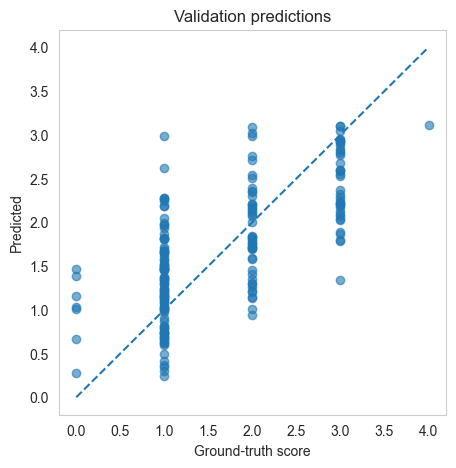

In [38]:
# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  Cell 10 – Quick scatter plot (pred vs actual)                        ║
# ╚═══════════════════════════════════════════════════════════════════════╝
model.load_state_dict(torch.load("best_similarity.pth"))
model.eval(); preds, gts = [], []
with torch.no_grad():
    for x,y in vl_loader:
        p = model(x.to(DEVICE)).cpu().squeeze()*4
        preds.extend(p.tolist()); gts.extend((y*4).tolist())

plt.figure(figsize=(5,5))
plt.scatter(gts, preds, alpha=.6)
plt.plot([0,4],[0,4],'--')
plt.xlabel("Ground-truth score"); plt.ylabel("Predicted"); plt.grid()
plt.title("Validation predictions"); plt.show()


In [39]:
import pandas as pd
import os
import base64
from pathlib import Path
import json


def read_csv_and_get_scored_images(csv_path):
    """Read CSV file and return set of already scored child IDs for shape 16"""
    try:
        df = pd.read_csv(csv_path)
        # Filter for shape 16 and get unique child IDs that have been scored
        shape16_df = df[df['Shape'] == 16]
        scored_child_ids = set(shape16_df['Child ID'].dropna().astype(int))
        return scored_child_ids
    except Exception as e:
        print(f"Error reading CSV: {e}")
        return set()


def get_image_files(images_path):
    """Get all image files from the specified directory"""
    image_extensions = {'.jpg', '.jpeg', '.png', '.gif', '.bmp', '.tiff'}
    image_files = []

    try:
        path = Path(images_path)
        for file in path.iterdir():
            if file.is_file() and file.suffix.lower() in image_extensions:
                image_files.append(file)
        return sorted(image_files)
    except Exception as e:
        print(f"Error reading images directory: {e}")
        return []


def extract_child_id_from_filename(filename):
    """Extract child ID from filename - assumes filename contains the child ID"""
    # This function may need adjustment based on your filename format
    # Common patterns: "child_123.jpg", "123_drawing.png", etc.
    import re

    # Try to find numbers in filename
    numbers = re.findall(r'\d+', filename.stem)
    if numbers:
        return int(numbers[0])  # Return first number found
    return None


def image_to_base64(image_path):
    """Convert image to base64 string for embedding in HTML"""
    try:
        with open(image_path, 'rb') as img_file:
            img_data = img_file.read()
            img_base64 = base64.b64encode(img_data).decode('utf-8')
            # Determine image type
            ext = image_path.suffix.lower()
            if ext == '.jpg' or ext == '.jpeg':
                mime_type = 'image/jpeg'
            elif ext == '.png':
                mime_type = 'image/png'
            elif ext == '.gif':
                mime_type = 'image/gif'
            else:
                mime_type = 'image/jpeg'  # default

            return f"data:{mime_type};base64,{img_base64}"
    except Exception as e:
        print(f"Error converting image {image_path}: {e}")
        return None


def create_html_template(images_data, tester_id, output_filename):
    """Create HTML file with images and scoring interface"""

    html_content = f'''<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Drawing Evaluation - Tester {tester_id}</title>
    <style>
        body {{
            font-family: Arial, sans-serif;
            max-width: 1200px;
            margin: 0 auto;
            padding: 20px;
            background-color: #f5f5f5;
        }}
        .header {{
            text-align: center;
            background-color: #4CAF50;
            color: white;
            padding: 20px;
            border-radius: 10px;
            margin-bottom: 30px;
        }}
        .image-container {{
            background-color: white;
            border-radius: 10px;
            padding: 20px;
            margin-bottom: 20px;
            box-shadow: 0 2px 5px rgba(0,0,0,0.1);
        }}
        .image-wrapper {{
            text-align: center;
            margin-bottom: 15px;
        }}
        .drawing-image {{
            max-width: 100%;
            max-height: 400px;
            border: 2px solid #ddd;
            border-radius: 5px;
        }}
        .score-input {{
            width: 100px;
            padding: 8px;
            font-size: 16px;
            border: 2px solid #ddd;
            border-radius: 5px;
            text-align: center;
        }}
        .child-id {{
            font-weight: bold;
            color: #333;
            margin-bottom: 10px;
        }}
        .download-section {{
            position: fixed;
            bottom: 20px;
            right: 20px;
            background-color: #2196F3;
            padding: 15px;
            border-radius: 10px;
            box-shadow: 0 4px 8px rgba(0,0,0,0.2);
        }}
        .download-btn {{
            background-color: #4CAF50;
            color: white;
            padding: 10px 20px;
            border: none;
            border-radius: 5px;
            cursor: pointer;
            font-size: 16px;
        }}
        .download-btn:hover {{
            background-color: #45a049;
        }}
        .progress {{
            margin-top: 10px;
            color: white;
            font-weight: bold;
        }}
        .instructions {{
            background-color: #e7f3ff;
            padding: 15px;
            border-radius: 5px;
            margin-bottom: 20px;
            border-left: 4px solid #2196F3;
        }}
    </style>
</head>
<body>
    <div class="header">
        <h1>Drawing Evaluation System</h1>
        <h2>Tester {tester_id}</h2>
        <p>Shape 16 Evaluation</p>
    </div>

    <div class="instructions">
        <strong>Instructions:</strong>
        <ul>
            <li>Look at each drawing carefully</li>
            <li>Enter a score in the text box below each image</li>
            <li>Your progress is automatically saved as you type</li>
            <li>Click "Download Results" when finished to get your scoring data</li>
        </ul>
    </div>

    <div id="images-container">
'''

    # Add images to HTML
    for i, (child_id, img_base64, filename) in enumerate(images_data):
        html_content += f'''
        <div class="image-container">
            <div class="child-id">Child ID: {child_id} | File: {filename}</div>
            <div class="image-wrapper">
                <img src="{img_base64}" alt="Drawing {child_id}" class="drawing-image">
            </div>
            <div style="text-align: center;">
                <label for="score_{child_id}">Score: </label>
                <input type="number" id="score_{child_id}" class="score-input"
                       placeholder="0-100" min="0" max="100"
                       onchange="saveScore({child_id}, this.value)"
                       oninput="updateProgress()">
            </div>
        </div>
        '''

    html_content += f'''
    </div>

    <div class="download-section">
        <button class="download-btn" onclick="downloadResults()">Download Results</button>
        <div class="progress" id="progress">Scored: 0/{len(images_data)}</div>
    </div>

    <script>
        // Load saved scores from localStorage
        function loadSavedScores() {{
            const savedScores = JSON.parse(localStorage.getItem('tester_{tester_id}_scores') || '{{}}');
            for (const childId in savedScores) {{
                const input = document.getElementById('score_' + childId);
                if (input) {{
                    input.value = savedScores[childId];
                }}
            }}
            updateProgress();
        }}

        // Save score to localStorage
        function saveScore(childId, score) {{
            const savedScores = JSON.parse(localStorage.getItem('tester_{tester_id}_scores') || '{{}}');
            if (score === '' || score === null) {{
                delete savedScores[childId];
            }} else {{
                savedScores[childId] = parseInt(score);
            }}
            localStorage.setItem('tester_{tester_id}_scores', JSON.stringify(savedScores));
            updateProgress();
        }}

        // Update progress counter
        function updateProgress() {{
            const savedScores = JSON.parse(localStorage.getItem('tester_{tester_id}_scores') || '{{}}');
            const totalImages = {len(images_data)};
            const scoredCount = Object.keys(savedScores).length;
            document.getElementById('progress').textContent = `Scored: ${{scoredCount}}/${{totalImages}}`;
        }}

        // Download results as CSV
        function downloadResults() {{
            const savedScores = JSON.parse(localStorage.getItem('tester_{tester_id}_scores') || '{{}}');

            if (Object.keys(savedScores).length === 0) {{
                alert('No scores entered yet!');
                return;
            }}

            let csvContent = 'child_id,score\\n';
            for (const childId in savedScores) {{
                csvContent += `${{childId}},${{savedScores[childId]}}\\n`;
            }}

            const blob = new Blob([csvContent], {{ type: 'text/csv' }});
            const url = window.URL.createObjectURL(blob);
            const a = document.createElement('a');
            a.href = url;
            a.download = `tester_{tester_id}_shape16_scores.csv`;
            document.body.appendChild(a);
            a.click();
            document.body.removeChild(a);
            window.URL.revokeObjectURL(url);
        }}

        // Load saved scores when page loads
        window.onload = loadSavedScores;
    </script>
</body>
</html>'''

    # Write HTML file
    try:
        with open(output_filename, 'w', encoding='utf-8') as f:
            f.write(html_content)
        print(f"Created {output_filename}")
        return True
    except Exception as e:
        print(f"Error creating {output_filename}: {e}")
        return False


def main():
    # Configuration
    csv_path = r"C:\Users\yozev\Downloads\drawing_evaluation_results (8).csv"
    images_path = r"C:\Users\yozev\OneDrive\Desktop\Shapes2\shape16"

    print("Starting drawing evaluation HTML generator...")

    # Step 1: Read CSV and get already scored images
    print("Reading CSV file...")
    scored_child_ids = read_csv_and_get_scored_images(csv_path)
    print(f"Found {len(scored_child_ids)} already scored images for shape 16")

    # Step 2: Get all image files
    print("Reading image files...")
    image_files = get_image_files(images_path)
    print(f"Found {len(image_files)} image files")

    # Step 3: Filter unscored images and prepare data
    print("Processing images...")
    unscored_images = []

    for img_file in image_files:
        child_id = extract_child_id_from_filename(img_file)
        if child_id is None:
            print(f"Warning: Could not extract child ID from {img_file.name}")
            continue

        if child_id not in scored_child_ids:
            img_base64 = image_to_base64(img_file)
            if img_base64:
                unscored_images.append((child_id, img_base64, img_file.name))

    print(f"Found {len(unscored_images)} unscored images")

    if len(unscored_images) == 0:
        print("No unscored images found. Exiting.")
        return

    # Step 4: Split images into 3 groups
    images_per_tester = len(unscored_images) // 3
    remainder = len(unscored_images) % 3

    tester_1_images = unscored_images[:images_per_tester + (1 if remainder > 0 else 0)]
    tester_2_images = unscored_images[
                      len(tester_1_images):len(tester_1_images) + images_per_tester + (1 if remainder > 1 else 0)]
    tester_3_images = unscored_images[len(tester_1_images) + len(tester_2_images):]

    print(f"Tester 1: {len(tester_1_images)} images")
    print(f"Tester 2: {len(tester_2_images)} images")
    print(f"Tester 3: {len(tester_3_images)} images")

    # Step 5: Create HTML files
    print("Creating HTML files...")

    success_count = 0
    if create_html_template(tester_1_images, 1, "tester_1_shape16_evaluation.html"):
        success_count += 1
    if create_html_template(tester_2_images, 2, "tester_2_shape16_evaluation.html"):
        success_count += 1
    if create_html_template(tester_3_images, 3, "tester_3_shape16_evaluation.html"):
        success_count += 1

    print(f"\nCompleted! Successfully created {success_count}/3 HTML files.")
    print("\nFiles created:")
    print("- tester_1_shape16_evaluation.html")
    print("- tester_2_shape16_evaluation.html")
    print("- tester_3_shape16_evaluation.html")
    print("\nEach tester can open their HTML file, score the images, and download their results as CSV.")


if __name__ == "__main__":
    main()

Starting drawing evaluation HTML generator...
Reading CSV file...
Found 266 already scored images for shape 16
Reading image files...
Found 897 image files
Processing images...
Found 632 unscored images
Tester 1: 211 images
Tester 2: 211 images
Tester 3: 210 images
Creating HTML files...
Created tester_1_shape16_evaluation.html
Created tester_2_shape16_evaluation.html
Created tester_3_shape16_evaluation.html

Completed! Successfully created 3/3 HTML files.

Files created:
- tester_1_shape16_evaluation.html
- tester_2_shape16_evaluation.html
- tester_3_shape16_evaluation.html

Each tester can open their HTML file, score the images, and download their results as CSV.
